In [1]:

import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
from matplotlib.pyplot import xticks
from mpl_toolkits.mplot3d.art3d import rotate_axes

In [2]:
df_cust = pd.read_csv('data/customers.csv')
df_cust.shape

(1000, 8)

In [3]:
df_ca = pd.read_csv('data/credit_profiles.csv')
df_ca.shape

(1004, 6)

In [4]:
df_trans = pd.read_csv("data/transactions.csv")
df_trans.shape

(500000, 7)

In [5]:
import mysql.connector as mc

In [6]:
conn = mc.connect(
    host = "localhost",
    user = "root",
    passwd = "Pass@123",
    database = "e_master_card"
)

In [7]:
df_cust = pd.read_sql("SELECT * FROM customers", conn)
df_cust.head()

C:\Users\vaibh\AppData\Local\Temp\ipykernel_19872\1487446849.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_cust = pd.read_sql("SELECT * FROM customers", conn)


,cust_id,name,gender,age,location,occupation,annual_income,marital_status
0,1,Manya Acharya,Female,2,City,Business Owner,358211,Married
1,2,Anjali Pandey,Female,47,City,Consultant,65172,Single
2,3,Aaryan Chauhan,Male,21,City,Freelancer,22378,Married
3,4,Rudra Bali,Male,24,Rural,Freelancer,33563,Married
4,5,Advait Malik,Male,48,City,Consultant,39406,Married


In [8]:
df_trans = pd.read_sql("SELECT * FROM transactions", conn)
df_trans.head()

C:\Users\vaibh\AppData\Local\Temp\ipykernel_19872\90138623.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_trans = pd.read_sql("SELECT * FROM transactions", conn)


,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
0,1,705,2023-01-01,63,Flipkart,Electronics,Phonepe
1,2,385,2023-01-01,99,Alibaba,Fashion & Apparel,Credit Card
2,3,924,2023-01-01,471,Shopify,Sports,Phonepe
3,4,797,2023-01-01,33,Shopify,Fashion & Apparel,Gpay
4,5,482,2023-01-01,68,Amazon,Fashion & Apparel,Net Banking


In [9]:
df_cs = pd.read_sql("SELECT * FROM credit_profiles", conn)
df_cs.head()

C:\Users\vaibh\AppData\Local\Temp\ipykernel_19872\1858606683.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_cs = pd.read_sql("SELECT * FROM credit_profiles", conn)


,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit
0,1,749,0.585171,19571.0,0.0,40000.0
1,2,587,0.107928,161644.0,2.0,1250.0
2,3,544,0.854807,513.0,4.0,1000.0
3,4,504,0.336938,224.0,2.0,1000.0
4,5,708,0.586151,18090.0,2.0,40000.0


In [10]:
df_cust.describe()

,cust_id,age,annual_income
count,1000.000000,1000.000000,1000.000000
mean,500.500000,36.405000,132439.799000
std,288.819436,15.666155,113706.313793
min,1.000000,1.000000,0.000000
25%,250.750000,26.000000,42229.750000
50%,500.500000,32.000000,107275.000000
75%,750.250000,46.000000,189687.500000
max,1000.000000,135.000000,449346.000000


In [11]:
df_cust.isnull().sum()

cust_id           0
name              0
gender            0
age               0
location          0
occupation        0
annual_income     0
marital_status    0
dtype: int64

In [12]:
occ_wise_inc_median = df_cust.groupby('occupation')['annual_income'].median()
occ_wise_inc_median

occupation
Accountant              65265.0
Artist                  44915.0
Business Owner         254881.0
Consultant              51175.0
Data Scientist         127889.0
Freelancer              45189.5
Fullstack Developer     74457.0
Name: annual_income, dtype: float64

<Axes: >

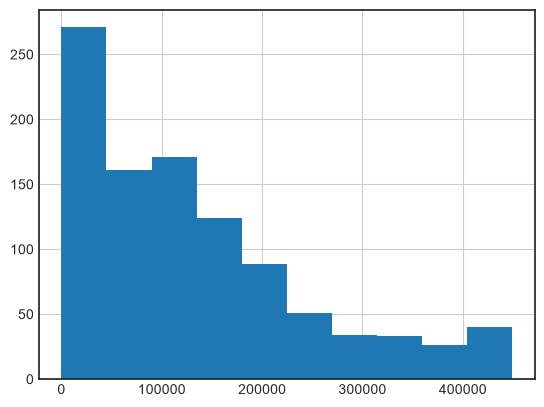

In [13]:
df_cust.annual_income.hist()

In [14]:
df_cust.annual_income.median()

np.float64(107275.0)

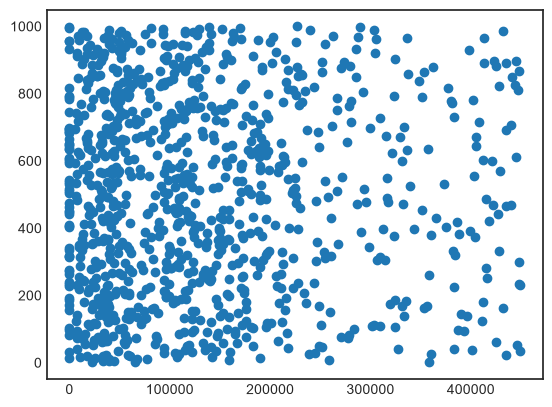

In [15]:
plt.scatter(df_cust.annual_income, df_cust.cust_id)

In [16]:
df_cust.head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
0,1,Manya Acharya,Female,2,City,Business Owner,358211,Married
1,2,Anjali Pandey,Female,47,City,Consultant,65172,Single
2,3,Aaryan Chauhan,Male,21,City,Freelancer,22378,Married
3,4,Rudra Bali,Male,24,Rural,Freelancer,33563,Married
4,5,Advait Malik,Male,48,City,Consultant,39406,Married


C:\Users\vaibh\AppData\Local\Temp\ipykernel_19872\3118479888.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


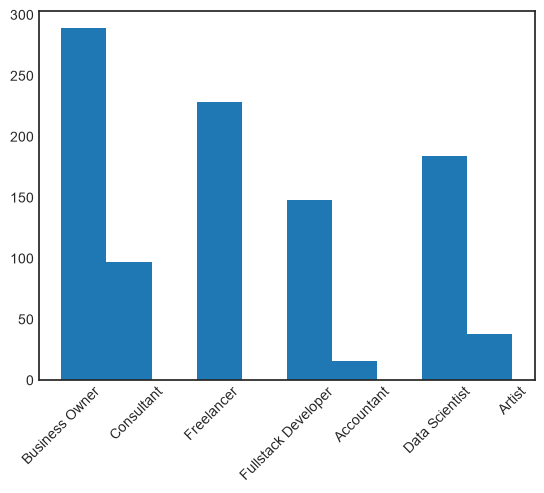

In [17]:
plt.hist(df_cust.occupation)
plt.xticks(rotation=45)
plt.legend()
plt.show()


In [18]:
df_cust.groupby('occupation')['occupation'].count()

occupation
Accountant              16
Artist                  38
Business Owner         289
Consultant              97
Data Scientist         184
Freelancer             228
Fullstack Developer    148
Name: occupation, dtype: int64

In [19]:
df_cust.groupby('occupation')['annual_income'].median()

occupation
Accountant              65265.0
Artist                  44915.0
Business Owner         254881.0
Consultant              51175.0
Data Scientist         127889.0
Freelancer              45189.5
Fullstack Developer     74457.0
Name: annual_income, dtype: float64

In [20]:
df_cust.columns

Index(['cust_id', 'name', 'gender', 'age', 'location', 'occupation',
       'annual_income', 'marital_status'],
      dtype='str')

In [21]:
import seaborn as sns

<Axes: xlabel='annual_income', ylabel='Count'>

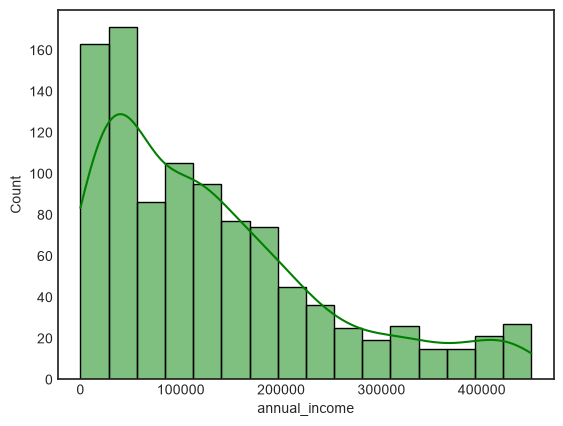

In [22]:
sns.histplot(df_cust.annual_income, kde = True, color = 'green', label = 'Data')

In [23]:
dff = df_cust[df_cust.annual_income == 0]

In [24]:
dff.head()


,cust_id,name,gender,age,location,occupation,annual_income,marital_status
14,15,Sanjana Malik,Female,25,Rural,Artist,0,Married
82,83,Reyansh Mukherjee,Male,27,City,Freelancer,0,Single
97,98,Virat Puri,Male,47,Suburb,Business Owner,0,Married
102,103,Aarav Shah,Male,32,City,Data Scientist,0,Married
155,156,Kiaan Saxena,Male,24,City,Fullstack Developer,0,Married


In [25]:
df_cust["annual_income"] = df_cust["annual_income"].replace(0, np.nan)

In [26]:
dff = df_cust[df_cust.annual_income == 0]

In [27]:
dff.shape

(0, 8)

In [28]:
df_cust.describe()

,cust_id,age,annual_income
count,1000.000000,1000.000000,950.000000
mean,500.500000,36.405000,139410.314737
std,288.819436,15.666155,112416.802007
min,1.000000,1.000000,2.000000
25%,250.750000,26.000000,47627.500000
50%,500.500000,32.000000,112218.500000
75%,750.250000,46.000000,193137.500000
max,1000.000000,135.000000,449346.000000


In [29]:
df_cust.isnull().sum()

cust_id            0
name               0
gender             0
age                0
location           0
occupation         0
annual_income     50
marital_status     0
dtype: int64

In [30]:
occ_wise_inc_median = df_cust.groupby('occupation')['annual_income'].median()
occ_wise_inc_median

occupation
Accountant              65265.0
Artist                  45794.0
Business Owner         261191.5
Consultant              58017.0
Data Scientist         135759.0
Freelancer              46759.0
Fullstack Developer     76774.0
Name: annual_income, dtype: float64

In [31]:
df_cust['annual_income'] = df_cust.apply(
    lambda x : occ_wise_inc_median[x['occupation']]
    if pd.isnull(x['annual_income'])
    else x['annual_income'],
    axis = 1
)

In [32]:
df_cust.isnull().sum()

cust_id           0
name              0
gender            0
age               0
location          0
occupation        0
annual_income     0
marital_status    0
dtype: int64

In [33]:
df_cust.describe()

,cust_id,age,annual_income
count,1000.000000,1000.000000,1000.000000
mean,500.500000,36.405000,138916.765500
std,288.819436,15.666155,110969.408643
min,1.000000,1.000000,2.000000
25%,250.750000,26.000000,48229.500000
50%,500.500000,32.000000,113416.000000
75%,750.250000,46.000000,192614.000000
max,1000.000000,135.000000,449346.000000


In [34]:
df_cust.groupby('occupation')['annual_income'].median()

occupation
Accountant              65265.0
Artist                  45794.0
Business Owner         261191.5
Consultant              58017.0
Data Scientist         135759.0
Freelancer              46759.0
Fullstack Developer     76774.0
Name: annual_income, dtype: float64

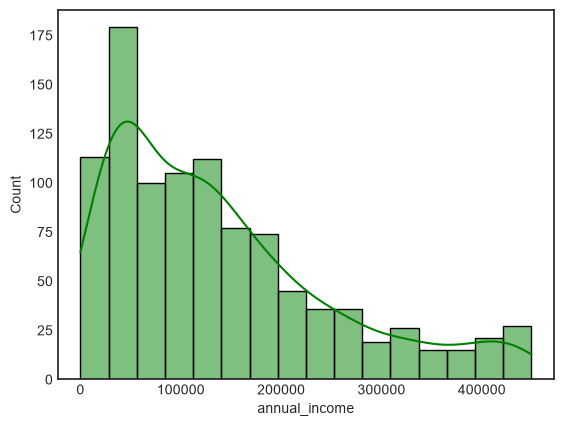

In [35]:
sns.histplot(df_cust.annual_income, kde = True, color = 'green', label = 'Data')
plt.show()

In [36]:
df_cust.describe()


,cust_id,age,annual_income
count,1000.000000,1000.000000,1000.000000
mean,500.500000,36.405000,138916.765500
std,288.819436,15.666155,110969.408643
min,1.000000,1.000000,2.000000
25%,250.750000,26.000000,48229.500000
50%,500.500000,32.000000,113416.000000
75%,750.250000,46.000000,192614.000000
max,1000.000000,135.000000,449346.000000


In [37]:
df_cust[df_cust['annual_income'] < 100]

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
31,32,Veer Mistry,Male,50,City,Business Owner,50.0,Married
262,263,Vivaan Tandon,Male,53,Suburb,Business Owner,50.0,Married
316,317,Yuvraj Saxena,Male,47,City,Consultant,50.0,Married
333,334,Avani Khanna,Female,29,City,Data Scientist,50.0,Married
340,341,Priya Sinha,Female,33,Rural,Fullstack Developer,50.0,Married
543,544,Advait Batra,Male,54,City,Consultant,2.0,Married
592,593,Priya Gandhi,Female,32,City,Business Owner,50.0,Married
633,634,Rudra Mehtani,Male,26,City,Data Scientist,2.0,Married
686,687,Vihaan Jaiswal,Male,40,City,Business Owner,2.0,Married
696,697,Ishan Negi,Male,47,City,Consultant,20.0,Married


In [38]:
for index, row in df_cust.iterrows():
    if row['annual_income'] < 100:
        df_cust.at[index, 'annual_income'] = occ_wise_inc_median[row['occupation']]


In [39]:
df_cust[df_cust['annual_income'] < 100]

,cust_id,name,gender,age,location,occupation,annual_income,marital_status


In [40]:
df_cust.iloc[[31, 262]]

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
31,32,Veer Mistry,Male,50,City,Business Owner,261191.5,Married
262,263,Vivaan Tandon,Male,53,Suburb,Business Owner,261191.5,Married


In [41]:
occ_wise_cust_avg_income = df_cust.groupby('occupation')['annual_income'].mean()
occ_wise_cust_avg_income

occupation
Accountant              64123.562500
Artist                  45309.236842
Business Owner         268447.368512
Consultant              60703.154639
Data Scientist         137021.266304
Freelancer              76327.508772
Fullstack Developer     78727.972973
Name: annual_income, dtype: float64

In [42]:
occ_wise_cust_avg_income.index

Index(['Accountant', 'Artist', 'Business Owner', 'Consultant',
       'Data Scientist', 'Freelancer', 'Fullstack Developer'],
      dtype='str', name='occupation')

In [43]:
occ_wise_cust_avg_income.values

array([ 64123.5625    ,  45309.23684211, 268447.36851211,  60703.15463918,
       137021.26630435,  76327.50877193,  78727.97297297])

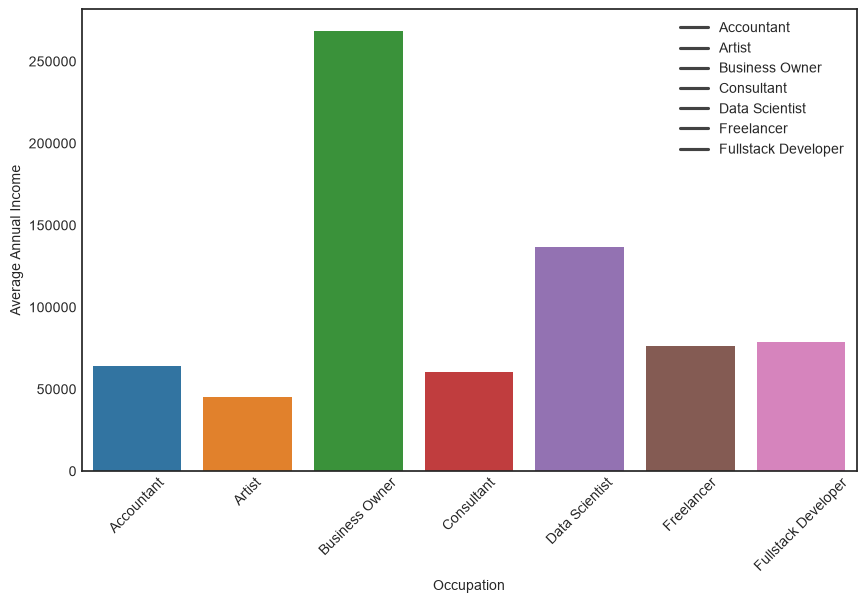

In [44]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=occ_wise_cust_avg_income.index,
    y=occ_wise_cust_avg_income.values,
    hue= occ_wise_cust_avg_income.index,
    palette = 'tab10'
)

plt.xticks(rotation=45)
plt.xlabel("Occupation")
plt.ylabel("Average Annual Income")
plt.legend(occ_wise_cust_avg_income.index)
plt.show()

In [45]:
df_cust.head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
0,1,Manya Acharya,Female,2,City,Business Owner,358211.0,Married
1,2,Anjali Pandey,Female,47,City,Consultant,65172.0,Single
2,3,Aaryan Chauhan,Male,21,City,Freelancer,22378.0,Married
3,4,Rudra Bali,Male,24,Rural,Freelancer,33563.0,Married
4,5,Advait Malik,Male,48,City,Consultant,39406.0,Married


C:\Users\vaibh\AppData\Local\Temp\ipykernel_19872\524143455.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


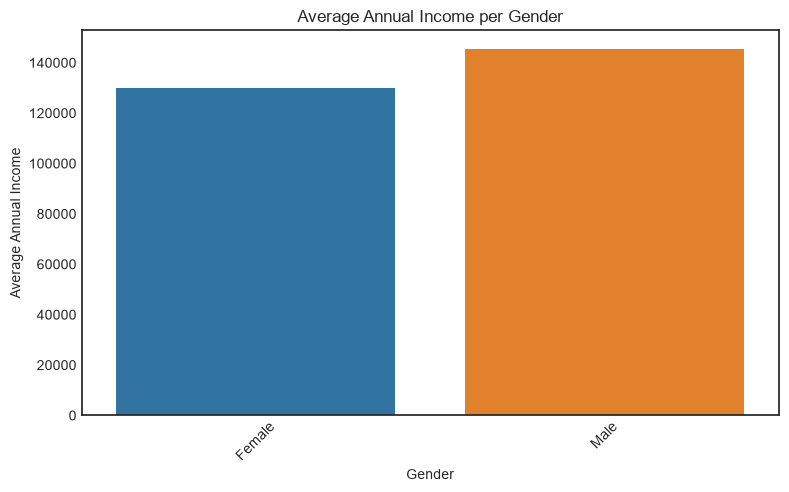

C:\Users\vaibh\AppData\Local\Temp\ipykernel_19872\524143455.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


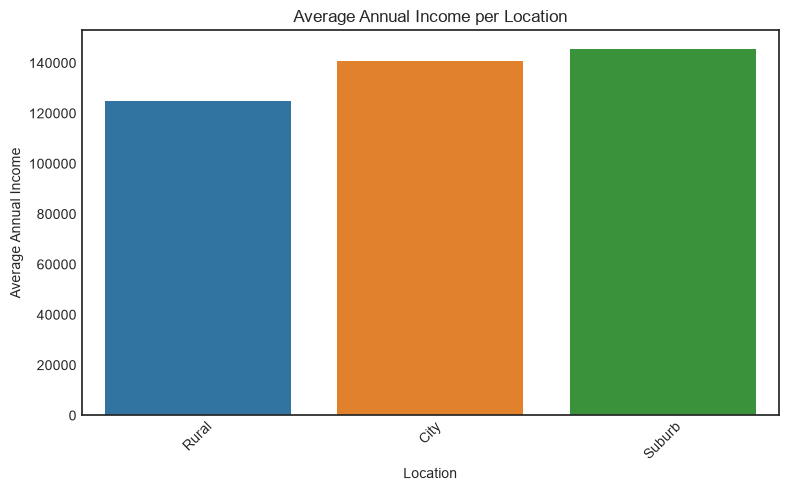

C:\Users\vaibh\AppData\Local\Temp\ipykernel_19872\524143455.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


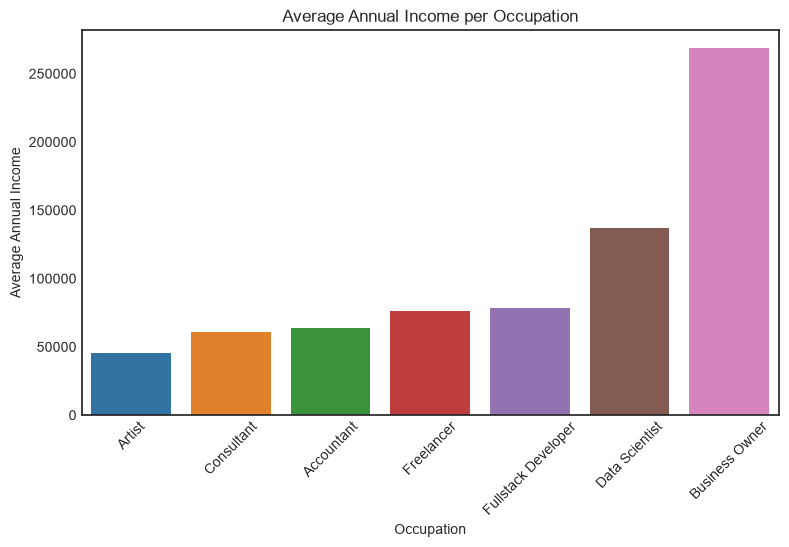

C:\Users\vaibh\AppData\Local\Temp\ipykernel_19872\524143455.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


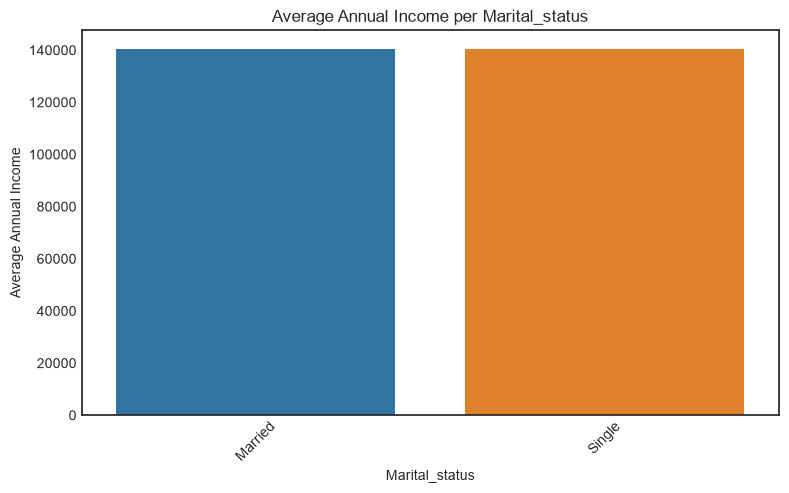

In [46]:
categorical_columns = ['gender', 'location', 'occupation', 'marital_status']

for col in categorical_columns:
    plt.figure(figsize=(9, 5))

    avg_inc_per_group = df_cust.groupby(col)['annual_income'].mean().sort_values(ascending = True)

    sns.barplot(
        x=avg_inc_per_group.index,
        y=avg_inc_per_group.values,
        palette='tab10'
    )

    plt.xticks(rotation=45)
    plt.xlabel(col.capitalize())
    plt.ylabel("Average Annual Income")
    plt.title(f"Average Annual Income per {col.capitalize()}")

    plt.show()



C:\Users\vaibh\AppData\Local\Temp\ipykernel_19872\3431238195.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\vaibh\AppData\Local\Temp\ipykernel_19872\3431238195.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\vaibh\AppData\Local\Temp\ipykernel_19872\3431238195.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\vaibh\AppData\Local\Temp\ipykernel_19872\3431238195.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `h

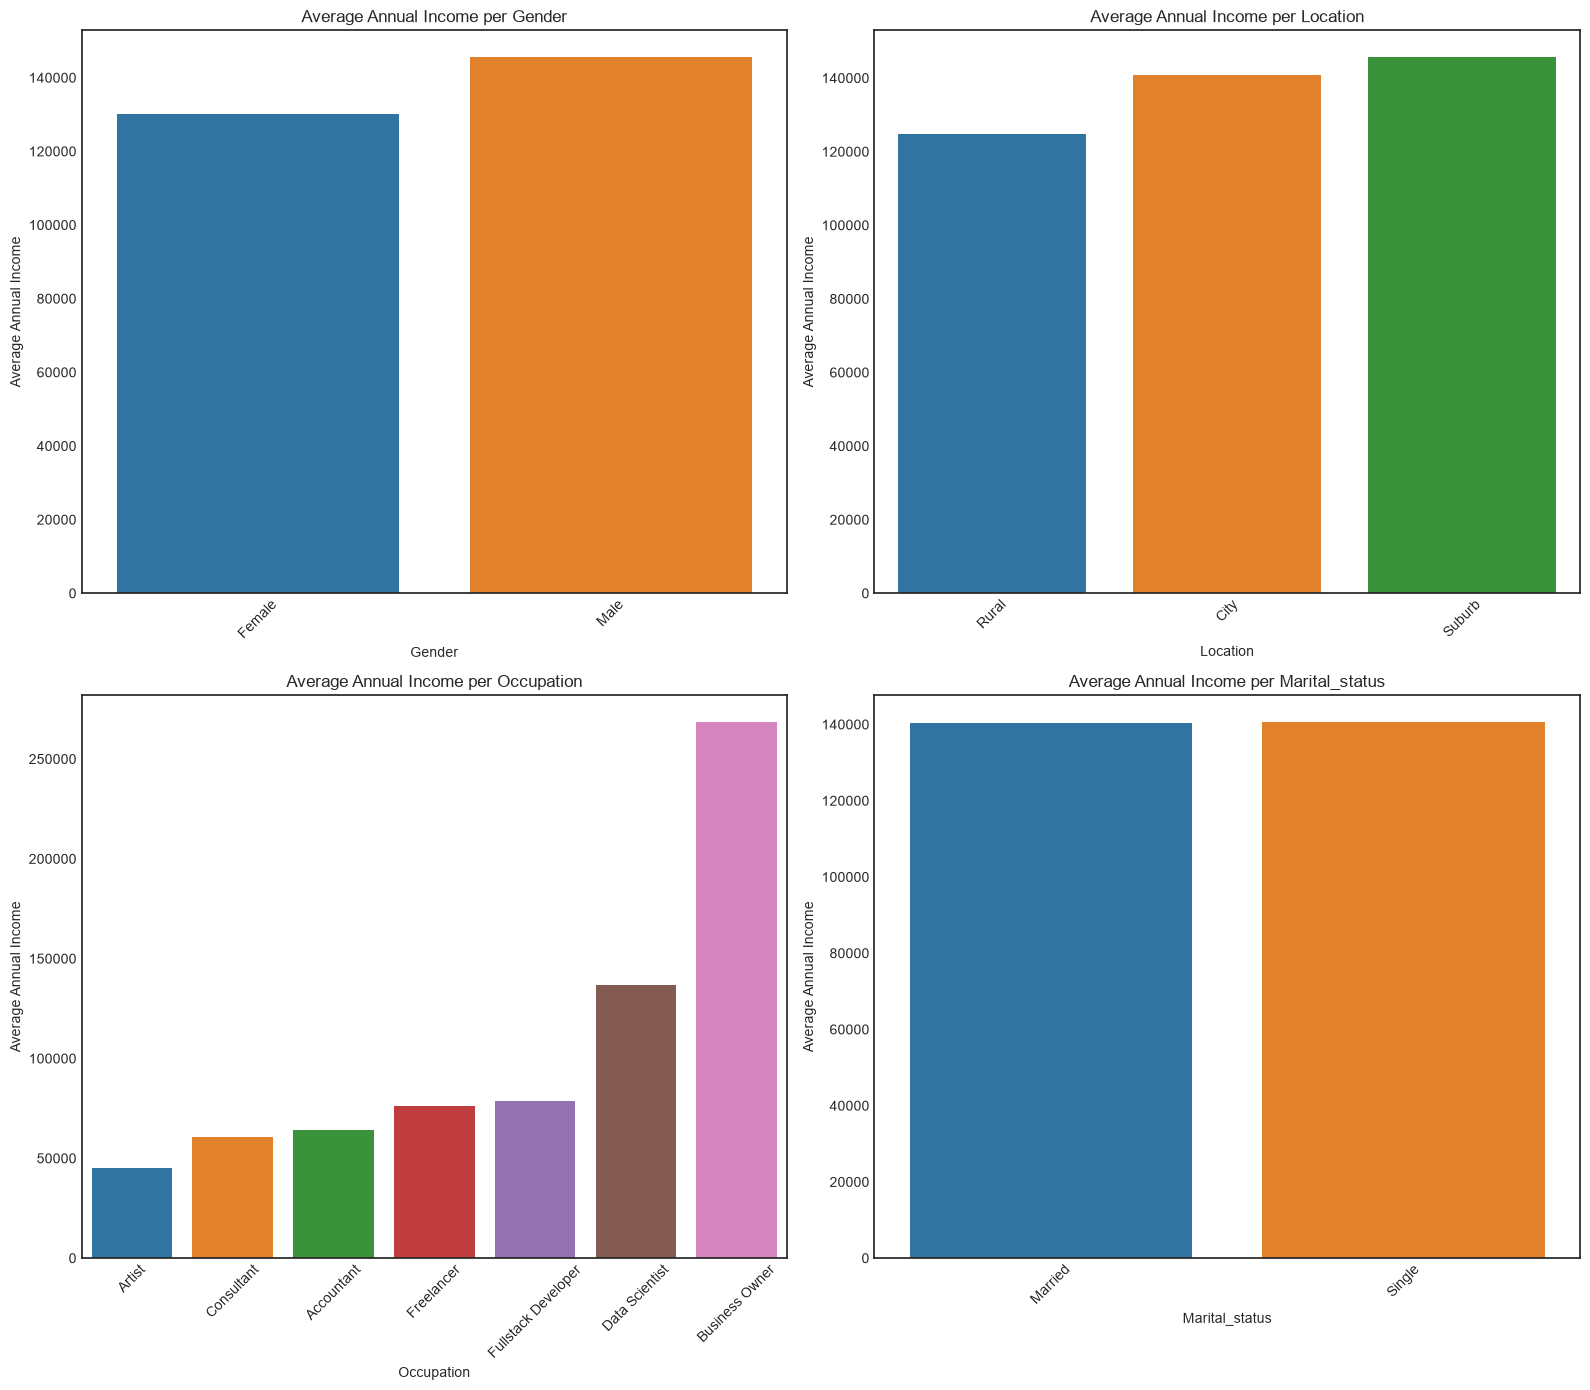

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_columns = ['gender', 'location', 'occupation', 'marital_status']

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()  # Convert 2x2 array to 1D array

for ax, col in zip(axes, categorical_columns):
    avg_inc_per_group = (
        df_cust.groupby(col)['annual_income']
        .mean()
        .sort_values(ascending=True)
    )

    sns.barplot(
        x=avg_inc_per_group.index,
        y=avg_inc_per_group.values,
        palette='tab10',
        ax=ax
    )

    ax.set_title(f"Average Annual Income per {col.capitalize()}")
    ax.set_xlabel(col.capitalize())
    ax.set_ylabel("Average Annual Income")
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [48]:
##

### Analyse Age Column

In [49]:
df_cust.age.isnull().sum()

np.int64(0)

In [50]:
df_cust.age.min()

np.int64(1)

In [51]:
df_cust.age.max()

np.int64(135)

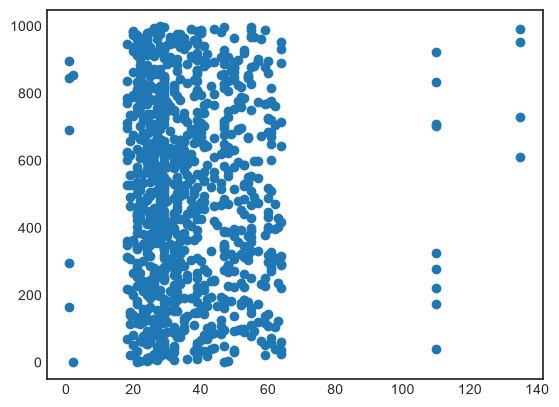

In [52]:
plt.scatter(df_cust.age, df_cust.age.index)

In [53]:
df_cust.head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
0,1,Manya Acharya,Female,2,City,Business Owner,358211.0,Married
1,2,Anjali Pandey,Female,47,City,Consultant,65172.0,Single
2,3,Aaryan Chauhan,Male,21,City,Freelancer,22378.0,Married
3,4,Rudra Bali,Male,24,Rural,Freelancer,33563.0,Married
4,5,Advait Malik,Male,48,City,Consultant,39406.0,Married


#### Age should be age > 15 AND age < 80

In [54]:
outliers = df_cust[(df_cust.age < 15) | (df_cust.age > 80)]
outliers.head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
0,1,Manya Acharya,Female,2,City,Business Owner,358211.0,Married
41,42,Aaryan Shah,Male,110,City,Artist,7621.0,Married
165,166,Sia Dutta,Female,1,City,Freelancer,39721.0,Single
174,175,Rohan Sharma,Male,110,City,Freelancer,23723.0,Married
222,223,Arjun Batra,Male,110,Suburb,Freelancer,210987.0,Married


In [55]:
median_age_per_occ = df_cust.groupby('occupation')['age'].median()
median_age_per_occ

occupation
Accountant             31.5
Artist                 26.0
Business Owner         51.0
Consultant             46.0
Data Scientist         32.0
Freelancer             24.0
Fullstack Developer    27.5
Name: age, dtype: float64

In [56]:
for index, row in df_cust.iterrows():
    if row['age'] < 15 or row['age'] > 80:
        df_cust.at[index, 'age'] = round(median_age_per_occ[row['occupation']])

In [57]:
outliers.shape

(20, 8)

In [58]:
df_cust[(df_cust.age < 15) | (df_cust.age > 80)]

,cust_id,name,gender,age,location,occupation,annual_income,marital_status


In [59]:
df_cust.describe()

,cust_id,age,annual_income
count,1000.000000,1000.000000,1000.000000
mean,500.500000,35.544000,140483.548500
std,288.819436,12.275372,110463.002934
min,1.000000,18.000000,5175.000000
25%,250.750000,26.000000,49620.500000
50%,500.500000,32.000000,115328.000000
75%,750.250000,44.250000,195514.250000
max,1000.000000,64.000000,449346.000000


In [60]:
bin_edges = [17, 25, 48, 65]
bin_labels = ['18-25', '26-48', '49-65']

df_cust['age_group'] = pd.cut(df_cust['age'], bins = bin_edges, labels = bin_labels)
df_cust.head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status,age_group
0,1,Manya Acharya,Female,51,City,Business Owner,358211.0,Married,49-65
1,2,Anjali Pandey,Female,47,City,Consultant,65172.0,Single,26-48
2,3,Aaryan Chauhan,Male,21,City,Freelancer,22378.0,Married,18-25
3,4,Rudra Bali,Male,24,Rural,Freelancer,33563.0,Married,18-25
4,5,Advait Malik,Male,48,City,Consultant,39406.0,Married,26-48


In [61]:
edge_group_counts = df_cust.age_group.value_counts(normalize=True)*100
edge_group_counts

age_group
26-48    56.7
18-25    24.6
49-65    18.7
Name: proportion, dtype: float64

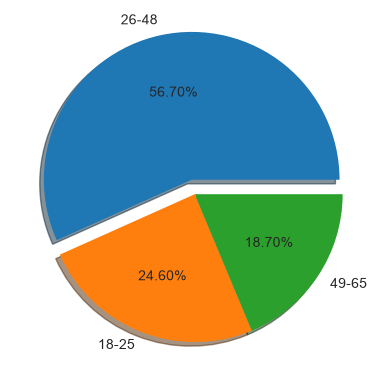

In [62]:
plt.pie(edge_group_counts,
        labels=df_cust.age_group.value_counts().index,
        autopct="%1.2f%%",
        shadow=True,
        startangle=0,
        explode = (0.1, 0, 0)
)
plt.show()

In [63]:
df_cust.groupby('location')['annual_income'].sum()

location
City      96086165.5
Rural     10610797.0
Suburb    33786586.0
Name: annual_income, dtype: float64

In [64]:
df_cust.location.value_counts()

location
City      683
Suburb    232
Rural      85
Name: count, dtype: int64

In [65]:
df_cust.groupby('gender')['annual_income'].sum()

gender
Female    42394712.0
Male      98088836.5
Name: annual_income, dtype: float64

In [66]:
df_cust.gender.value_counts()

gender
Male      674
Female    326
Name: count, dtype: int64

In [67]:
df_cust.groupby(['location', 'gender'])['annual_income'].sum()

location  gender
City      Female    30514837.0
          Male      65571328.5
Rural     Female     2442968.0
          Male       8167829.0
Suburb    Female     9436907.0
          Male      24349679.0
Name: annual_income, dtype: float64

In [68]:
df_cust.groupby(['location', 'gender']).size()

location  gender
City      Female    226
          Male      457
Rural     Female     26
          Male       59
Suburb    Female     74
          Male      158
dtype: int64

In [69]:
cus_loc_gnd = df_cust.groupby(['location', 'gender']).size().unstack()
cus_loc_gnd

gender,Female,Male
location,,
City,226,457
Rural,26,59
Suburb,74,158


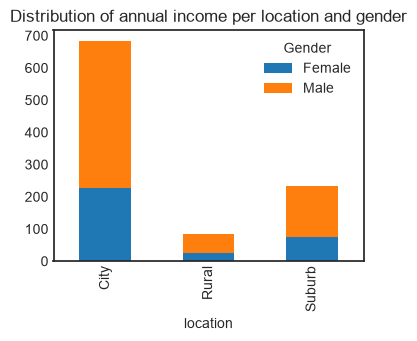

In [70]:
cus_loc_gnd.plot(kind = 'bar',
                 stacked = True,
                 figsize = (4, 3))
plt.title('Distribution of annual income per location and gender')
plt.legend(title='Gender')
plt.show()

## <font color="orange">Exploring Credit Score Table</font>.

## Credit Score Table Analysis

In [71]:
df_cs.shape

(1004, 6)

In [72]:
df_cs['cust_id'].nunique()

1000

In [73]:
df_cs[df_cs['cust_id'].duplicated(keep = 'last')]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit
516,517,308,NaN,NaN,NaN,NaN
569,569,344,NaN,NaN,NaN,NaN
607,606,734,NaN,NaN,NaN,NaN
664,662,442,NaN,NaN,NaN,NaN


In [74]:
df_cs_clean_1 = df_cs.drop_duplicates(subset=['cust_id'], keep='last')
df_cs_clean_1.shape

(1000, 6)

In [75]:
df_cs[df_cs.cust_id == 516]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit
515,516,555,0.391343,305.0,2.0,NaN


In [76]:
df_cs_clean_1.isnull().sum()

cust_id                            0
credit_score                       0
credit_utilisation                 0
outstanding_debt                   0
credit_inquiries_last_6_months     0
credit_limit                      65
dtype: int64

In [77]:
df_cs_clean_1[df_cs_clean_1.credit_limit.isnull()]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit
10,11,679,0.557450,9187.0,2.0,NaN
35,36,790,0.112535,4261.0,1.0,NaN
37,38,514,0.296971,238.0,2.0,NaN
45,46,761,0.596041,24234.0,2.0,NaN
64,65,734,0.473715,13631.0,0.0,NaN
...,...,...,...,...,...,...
912,909,479,0.487555,320.0,3.0,NaN
931,928,311,0.832244,316.0,2.0,NaN
948,945,526,0.272734,227.0,1.0,NaN
954,951,513,0.175914,131.0,3.0,NaN


In [78]:
df_cs_clean_1.credit_limit.value_counts()

credit_limit
500.0      229
60000.0    186
40000.0    137
1500.0     100
1000.0      90
750.0       76
1250.0      75
20000.0     42
Name: count, dtype: int64

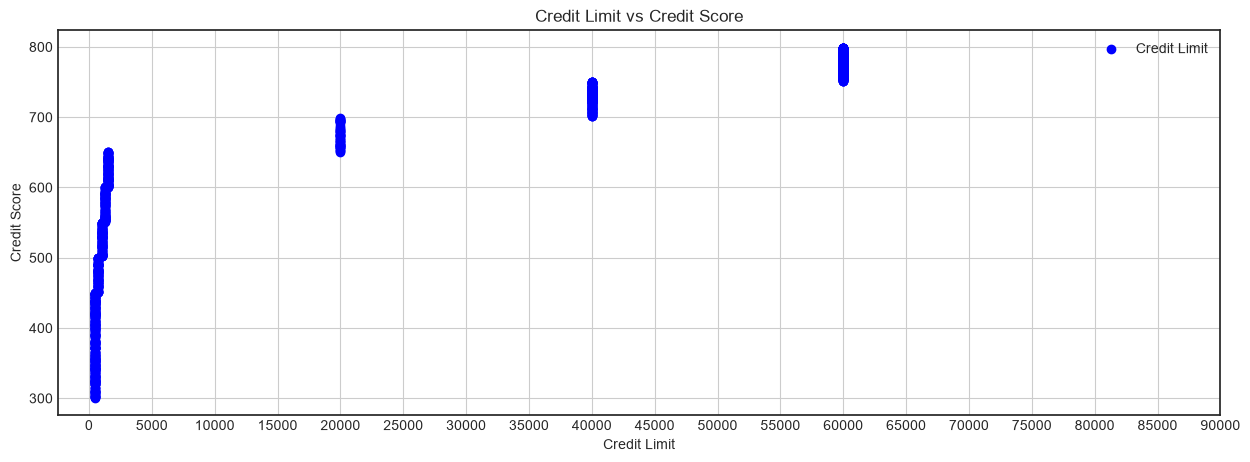

In [79]:

plt.figure(figsize=(15, 5))
plt.scatter(df_cs_clean_1.credit_limit, df_cs_clean_1.credit_score, c = 'blue', marker = 'o', label = 'Credit Limit')
plt.title('Credit Limit vs Credit Score')
plt.xlabel('Credit Limit')
plt.ylabel('Credit Score')

plt.xticks(range(0, 90001, 5000))
plt.grid(True)
plt.legend()
plt.show()

In [80]:
bin_ranges = [300, 450, 500, 550, 600, 650, 700, 750, 800]
bin_labels = [f"{start} - {end-1}" for start, end in zip(bin_ranges,
              bin_ranges[1:])]

df_cs_clean_1['credit_score_range'] = pd.cut(df_cs_clean_1['credit_score'], bins = bin_ranges, labels = bin_labels, include_lowest = True, right = False)

In [81]:
df_cs_clean_1.head()

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range
0,1,749,0.585171,19571.0,0.0,40000.0,700 - 749
1,2,587,0.107928,161644.0,2.0,1250.0,550 - 599
2,3,544,0.854807,513.0,4.0,1000.0,500 - 549
3,4,504,0.336938,224.0,2.0,1000.0,500 - 549
4,5,708,0.586151,18090.0,2.0,40000.0,700 - 749


In [82]:
df_cs_clean_1.columns

Index(['cust_id', 'credit_score', 'credit_utilisation', 'outstanding_debt',
       'credit_inquiries_last_6_months', 'credit_limit', 'credit_score_range'],
      dtype='str')

In [83]:
df_cs_clean_1['credit_score_range'].unique()

['700 - 749', '550 - 599', '500 - 549', '300 - 449', '450 - 499', '650 - 699', '600 - 649', '750 - 799']
Categories (8, str): ['300 - 449' < '450 - 499' < '500 - 549' < '550 - 599' < '600 - 649' < '650 - 699' < '700 - 749' < '750 - 799']

In [84]:
df_cs_clean_1[df_cs_clean_1['credit_score_range'] == "700 - 749"]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range
0,1,749,0.585171,19571.0,0.0,40000.0,700 - 749
4,5,708,0.586151,18090.0,2.0,40000.0,700 - 749
6,7,747,0.523965,15544.0,4.0,40000.0,700 - 749
16,17,702,0.894423,18444.0,0.0,40000.0,700 - 749
27,28,729,0.149748,3453.0,2.0,40000.0,700 - 749
...,...,...,...,...,...,...,...
969,966,720,0.203742,6159.0,4.0,40000.0,700 - 749
970,967,739,0.845474,23929.0,4.0,40000.0,700 - 749
991,988,739,0.435891,9283.0,4.0,40000.0,700 - 749
994,991,709,0.718484,15473.0,4.0,40000.0,700 - 749


In [85]:
mode_df = df_cs_clean_1.groupby('credit_score_range')['credit_limit'].agg(lambda x: x.mode().iloc[0]).reset_index()
mode_df

,credit_score_range,credit_limit
0,300 - 449,500.0
1,450 - 499,750.0
2,500 - 549,1000.0
3,550 - 599,1250.0
4,600 - 649,1500.0
5,650 - 699,20000.0
6,700 - 749,40000.0
7,750 - 799,60000.0


In [86]:
df_cs_clean_1[df_cs_clean_1.credit_limit.isnull()].head(3)

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range
10,11,679,0.557450,9187.0,2.0,NaN,650 - 699
35,36,790,0.112535,4261.0,1.0,NaN,750 - 799
37,38,514,0.296971,238.0,2.0,NaN,500 - 549


In [87]:
df_cs_clean_2 = pd.merge(df_cs_clean_1, mode_df, on = 'credit_score_range',
          suffixes=("", "_mode"))

In [88]:
df_cs_clean_2[df_cs_clean_2.credit_limit_mode.isnull()].head(3)

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode


In [89]:
df_cs_clean_2[df_cs_clean_2.credit_limit.isnull()].head(3)

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode
10,11,679,0.557450,9187.0,2.0,NaN,650 - 699,20000.0
35,36,790,0.112535,4261.0,1.0,NaN,750 - 799,60000.0
37,38,514,0.296971,238.0,2.0,NaN,500 - 549,1000.0


In [90]:
df_cs_clean_2['credit_limit'].fillna(df_cs_clean_2['credit_limit_mode'], inplace = True)

C:\Users\vaibh\AppData\Local\Temp\ipykernel_19872\1407924098.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_cs_clean_2['credit_limit'].fillna(df_cs_clean_2['credit_limit_mode'], inplace = True)


0      40000.0
1       1250.0
2       1000.0
3       1000.0
4      40000.0
        ...   
995     1250.0
996    60000.0
997     1000.0
998    40000.0
999    60000.0
Name: credit_limit, Length: 1000, dtype: float64

In [91]:
df_cs_clean_2['credit_limit'] = df_cs_clean_2['credit_limit'].fillna(df_cs_clean_2['credit_limit_mode'])

In [92]:
df_cs_clean_2[df_cs_clean_2.credit_limit.isnull()].head(3)

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode


In [93]:
df_cs_clean_3 = df_cs_clean_2.copy()

In [94]:
df_cs_clean_3.isnull().sum()

cust_id                           0
credit_score                      0
credit_utilisation                0
outstanding_debt                  0
credit_inquiries_last_6_months    0
credit_limit                      0
credit_score_range                0
credit_limit_mode                 0
dtype: int64

In [95]:
df_cs_clean_3.describe()

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_limit_mode
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,500.500000,589.182000,0.498950,9683.597000,1.955000,19733.75000,19912.500000
std,288.819436,152.284929,0.233139,25255.893671,1.414559,24717.43818,24840.914633
min,1.000000,300.000000,0.103761,33.000000,0.000000,500.00000,500.000000
25%,250.750000,460.000000,0.293917,221.000000,1.000000,750.00000,750.000000
50%,500.500000,601.500000,0.487422,550.000000,2.000000,1500.00000,1500.000000
75%,750.250000,738.000000,0.697829,11819.500000,3.000000,40000.00000,40000.000000
max,1000.000000,799.000000,0.899648,209901.000000,4.000000,60000.00000,60000.000000


<Axes: ylabel='outstanding_debt'>

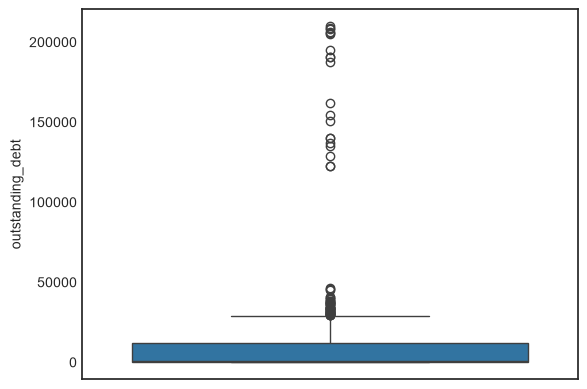

In [96]:
sns.boxplot(df_cs_clean_3.outstanding_debt)

<Axes: ylabel='outstanding_debt'>

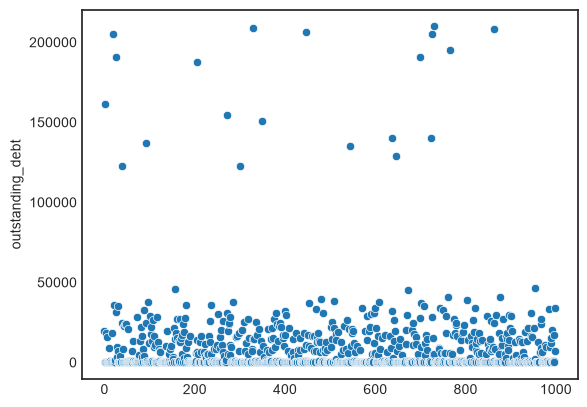

In [97]:
sns.scatterplot(df_cs_clean_3.outstanding_debt)

In [98]:
df_cs_clean_3[df_cs_clean_2.outstanding_debt > df_cs_clean_3.credit_limit]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode
1,2,587,0.107928,161644.0,2.0,1250.0,550 - 599,1250.0
19,20,647,0.439132,205014.0,3.0,1500.0,600 - 649,1500.0
25,26,758,0.250811,190838.0,2.0,60000.0,750 - 799,60000.0
38,39,734,0.573023,122758.0,3.0,40000.0,700 - 749,40000.0
93,94,737,0.739948,137058.0,2.0,40000.0,700 - 749,40000.0
204,205,303,0.364360,187849.0,0.0,500.0,300 - 449,500.0
271,272,703,0.446886,154568.0,1.0,40000.0,700 - 749,40000.0
301,302,722,0.608076,122402.0,4.0,40000.0,700 - 749,40000.0
330,331,799,0.363420,208898.0,4.0,60000.0,750 - 799,60000.0
350,351,320,0.285081,150860.0,0.0,500.0,300 - 449,500.0


In [99]:
df_cs_clean_3[df_cs_clean_2.outstanding_debt > df_cs_clean_3.credit_limit].count()

cust_id                           20
credit_score                      20
credit_utilisation                20
outstanding_debt                  20
credit_inquiries_last_6_months    20
credit_limit                      20
credit_score_range                20
credit_limit_mode                 20
dtype: int64

In [100]:
df_cs_clean_3.loc[df_cs_clean_3.outstanding_debt > df_cs_clean_3.credit_limit, 'outstanding_debt'] = df_cs_clean_3['credit_limit']


In [101]:
df_cs_clean_3[df_cs_clean_3.outstanding_debt > df_cs_clean_3.credit_limit]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode


In [102]:
df_cs_clean_3.sample(5)

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode
137,138,778,0.187598,10127.0,4.0,60000.0,750 - 799,60000.0
746,747,657,0.492158,5928.0,1.0,20000.0,650 - 699,20000.0
688,689,373,0.120801,52.0,4.0,500.0,300 - 449,500.0
5,6,442,0.705409,246.0,4.0,500.0,300 - 449,500.0
122,123,775,0.218366,7121.0,3.0,60000.0,750 - 799,60000.0


In [103]:
df_cust.sample()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status,age_group
800,801,Ayush Mhatre,Male,23,Suburb,Freelancer,53314.0,Married,18-25


In [104]:
df_merged = df_cust.merge(df_cs_clean_3, on = 'cust_id', how = 'inner')
df_merged.sample(5)

,cust_id,name,gender,age,location,occupation,annual_income,marital_status,age_group,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode
332,333,Aisha Sardar,Female,43,City,Business Owner,199099.0,Married,26-48,354,0.795606,358.0,1.0,500.0,300 - 449,500.0
322,323,Rehan Rao,Male,34,City,Data Scientist,99417.0,Married,26-48,469,0.565420,218.0,3.0,750.0,450 - 499,750.0
514,515,Kavya Banerjee,Female,50,City,Business Owner,293417.0,Married,49-65,764,0.292745,14111.0,2.0,60000.0,750 - 799,60000.0
866,867,Ishan Kapoor,Male,49,City,Business Owner,447655.0,Single,49-65,773,0.198927,8240.0,0.0,60000.0,750 - 799,60000.0
480,481,Mihika Pande,Female,30,City,Data Scientist,169350.0,Single,26-48,444,0.861890,294.0,3.0,500.0,300 - 449,500.0


In [105]:
df_merged[["credit_score", 'credit_limit']].corr()

,credit_score,credit_limit
credit_score,1.000000,0.847952
credit_limit,0.847952,1.000000


In [106]:
numerical_cols = ['credit_score', 'credit_utilisation', 'outstanding_debt',	'credit_limit', 'annual_income', 'age']
correlation_matrix = df_merged[numerical_cols].corr()
correlation_matrix

,credit_score,credit_utilisation,outstanding_debt,credit_limit,annual_income,age
credit_score,1.000000,-0.070445,0.680654,0.847952,0.575751,0.444870
credit_utilisation,-0.070445,1.000000,0.192838,-0.080493,-0.086368,-0.027598
outstanding_debt,0.680654,0.192838,1.000000,0.810581,0.555661,0.444223
credit_limit,0.847952,-0.080493,0.810581,1.000000,0.684775,0.510891
annual_income,0.575751,-0.086368,0.555661,0.684775,1.000000,0.618965
age,0.444870,-0.027598,0.444223,0.510891,0.618965,1.000000


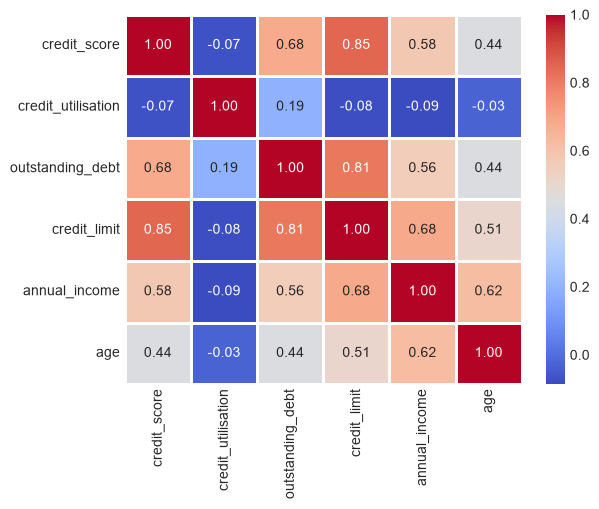

In [108]:
sns.heatmap(correlation_matrix, annot=True, fmt = ".2f", cmap = 'coolwarm',linewidths=.8)
plt.show()

## <font color = 'Orange'> Transaction Table </font>

In [109]:
df_trans.head()

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
0,1,705,2023-01-01,63,Flipkart,Electronics,Phonepe
1,2,385,2023-01-01,99,Alibaba,Fashion & Apparel,Credit Card
2,3,924,2023-01-01,471,Shopify,Sports,Phonepe
3,4,797,2023-01-01,33,Shopify,Fashion & Apparel,Gpay
4,5,482,2023-01-01,68,Amazon,Fashion & Apparel,Net Banking


In [110]:
df_trans.describe()

,tran_id,cust_id,tran_amount
count,500000.000000,500000.000000,500000.00000
mean,250000.500000,501.400428,3225.20733
std,144337.711635,288.641924,13098.74276
min,1.000000,1.000000,0.00000
25%,125000.750000,252.000000,64.00000
50%,250000.500000,502.000000,141.00000
75%,375000.250000,752.000000,397.00000
max,500000.000000,1000.000000,69999.00000


In [111]:
df_trans.isnull().sum()

tran_id                0
cust_id                0
tran_date              0
tran_amount            0
platform            4941
product_category       0
payment_type           0
dtype: int64

In [119]:
df_trans[df_trans.platform.isnull()]

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
355,356,58,2023-01-01,237,NaN,Electronics,Net Banking
418,419,383,2023-01-01,338,NaN,Electronics,Credit Card
607,608,421,2023-01-01,700,NaN,Electronics,Phonepe
844,845,945,2023-01-01,493,NaN,Sports,Credit Card
912,913,384,2023-01-01,85,NaN,Fashion & Apparel,Phonepe
...,...,...,...,...,...,...,...
499579,499580,924,2023-09-05,31,NaN,Fashion & Apparel,Gpay
499646,499647,944,2023-09-05,58445,NaN,Fashion & Apparel,Phonepe
499725,499726,620,2023-09-05,15,NaN,Sports,Net Banking
499833,499834,616,2023-09-05,97,NaN,Fashion & Apparel,Credit Card


In [122]:
df_trans.platform.unique()

<StringArray>
['Flipkart', 'Alibaba', 'Shopify', 'Amazon', 'Ebay', 'Meesho', 'Cred', nan]
Length: 8, dtype: str

In [131]:
df_trans.platform.agg(lambda x: x.mode().iloc[0])

'Amazon'

In [132]:
df_trans.platform.value_counts()

platform
Amazon      151443
Flipkart    122660
Alibaba      73584
Meesho       73271
Shopify      39416
Cred         24741
Ebay          9944
Name: count, dtype: int64

In [133]:
df_trans.product_category.value_counts()

product_category
Electronics               134535
Fashion & Apparel         116892
Kitchen Appliances         57353
Beauty & Personal Care     56065
Sports                     49704
Home Decor                 38355
Garden & Outdoor           23644
Books                      13635
Toys & Games                9817
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='product_category'>

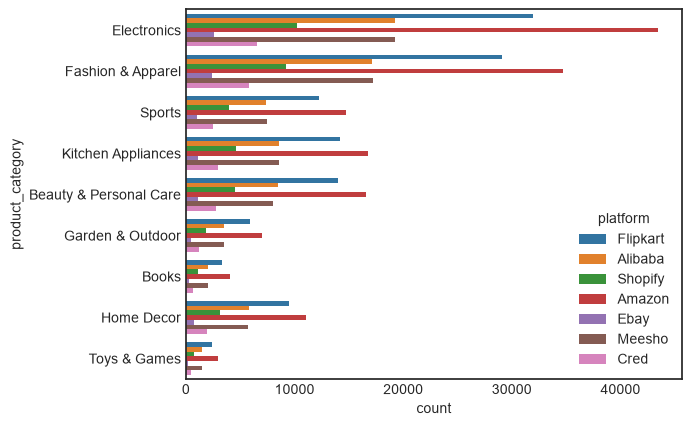

In [134]:
sns.countplot(data = df_trans, y = 'product_category', hue = 'platform')

In [137]:
df_trans.platform.mode()[0]

'Amazon'

In [147]:
df_trans['platform']= df_trans.platform.fillna(df_trans.platform.mode()[0])

In [148]:
df_trans.isnull().sum()

tran_id             0
cust_id             0
tran_date           0
tran_amount         0
platform            0
product_category    0
payment_type        0
dtype: int64

In [151]:
df_trans.value_counts()

tran_id  cust_id  tran_date   tran_amount  platform  product_category    payment_type
1        705      2023-01-01  63           Flipkart  Electronics         Phonepe         1
2        385      2023-01-01  99           Alibaba   Fashion & Apparel   Credit Card     1
3        924      2023-01-01  471          Shopify   Sports              Phonepe         1
4        797      2023-01-01  33           Shopify   Fashion & Apparel   Gpay            1
5        482      2023-01-01  68           Amazon    Fashion & Apparel   Net Banking     1
                                                                                        ..
499996   791      2023-09-05  43           Amazon    Books               Phonepe         1
499997   569      2023-09-05  53022        Meesho    Fashion & Apparel   Net Banking     1
499998   57       2023-09-05  224          Amazon    Garden & Outdoor    Phonepe         1
499999   629      2023-09-05  538          Flipkart  Home Decor          Gpay            1
5000

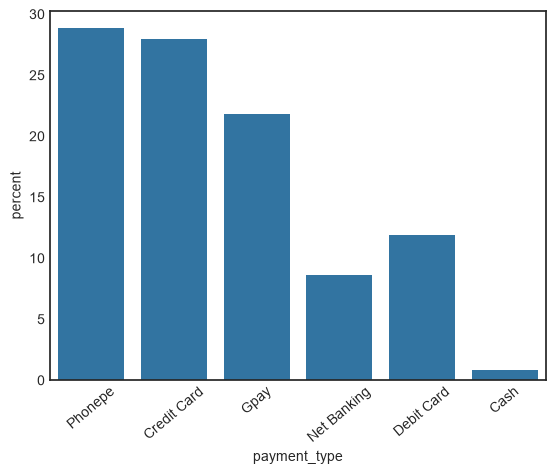

In [156]:
sns.countplot(x = df_trans.payment_type, stat = "percent")
plt.xticks(rotation = 40)
plt.show()

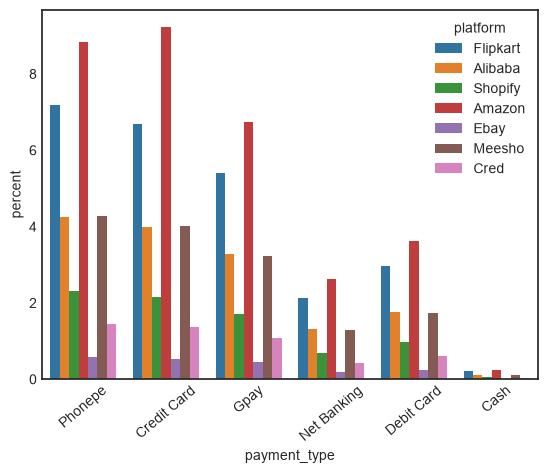

In [158]:
sns.countplot(x = df_trans.payment_type, hue = df_trans.platform , stat = "percent")
plt.xticks(rotation = 40)
plt.show()

In [159]:
df_merged.head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status,age_group,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode
0,1,Manya Acharya,Female,51,City,Business Owner,358211.0,Married,49-65,749,0.585171,19571.0,0.0,40000.0,700 - 749,40000.0
1,2,Anjali Pandey,Female,47,City,Consultant,65172.0,Single,26-48,587,0.107928,1250.0,2.0,1250.0,550 - 599,1250.0
2,3,Aaryan Chauhan,Male,21,City,Freelancer,22378.0,Married,18-25,544,0.854807,513.0,4.0,1000.0,500 - 549,1000.0
3,4,Rudra Bali,Male,24,Rural,Freelancer,33563.0,Married,18-25,504,0.336938,224.0,2.0,1000.0,500 - 549,1000.0
4,5,Advait Malik,Male,48,City,Consultant,39406.0,Married,26-48,708,0.586151,18090.0,2.0,40000.0,700 - 749,40000.0


In [160]:
df_merged_1 = pd.merge(df_merged, df_trans, on = 'cust_id', how = 'inner')

In [161]:
df_merged_1.head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status,age_group,credit_score,...,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode,tran_id,tran_date,tran_amount,platform,product_category,payment_type
0,1,Manya Acharya,Female,51,City,Business Owner,358211.0,Married,49-65,749,...,0.0,40000.0,700 - 749,40000.0,1283,2023-01-01,30,Shopify,Fashion & Apparel,Net Banking
1,1,Manya Acharya,Female,51,City,Business Owner,358211.0,Married,49-65,749,...,0.0,40000.0,700 - 749,40000.0,1382,2023-01-01,96,Amazon,Sports,Debit Card
2,1,Manya Acharya,Female,51,City,Business Owner,358211.0,Married,49-65,749,...,0.0,40000.0,700 - 749,40000.0,1521,2023-01-01,86,Meesho,Garden & Outdoor,Gpay
3,1,Manya Acharya,Female,51,City,Business Owner,358211.0,Married,49-65,749,...,0.0,40000.0,700 - 749,40000.0,1576,2023-01-01,149,Amazon,Beauty & Personal Care,Phonepe
4,1,Manya Acharya,Female,51,City,Business Owner,358211.0,Married,49-65,749,...,0.0,40000.0,700 - 749,40000.0,1757,2023-01-01,37,Flipkart,Fashion & Apparel,Credit Card


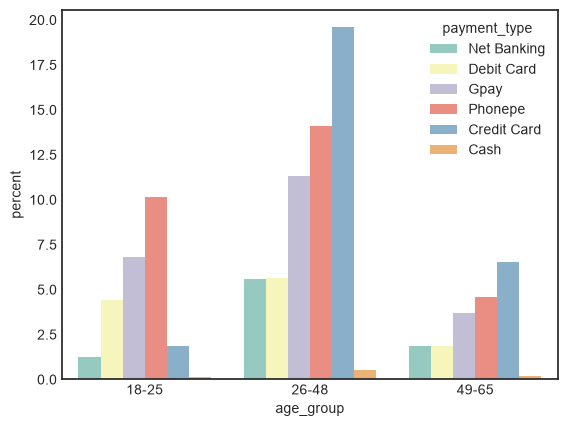

In [176]:
sns.countplot(x = df_merged_1.age_group, hue = df_merged_1.payment_type , stat = "percent", palette = 'Set3')

plt.show()

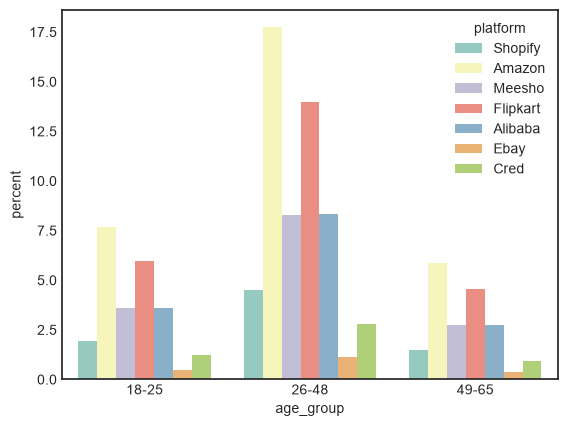

In [178]:
sns.countplot(x = df_merged_1.age_group, hue = df_merged_1.platform , stat = "percent", palette = 'Set3')

plt.show()

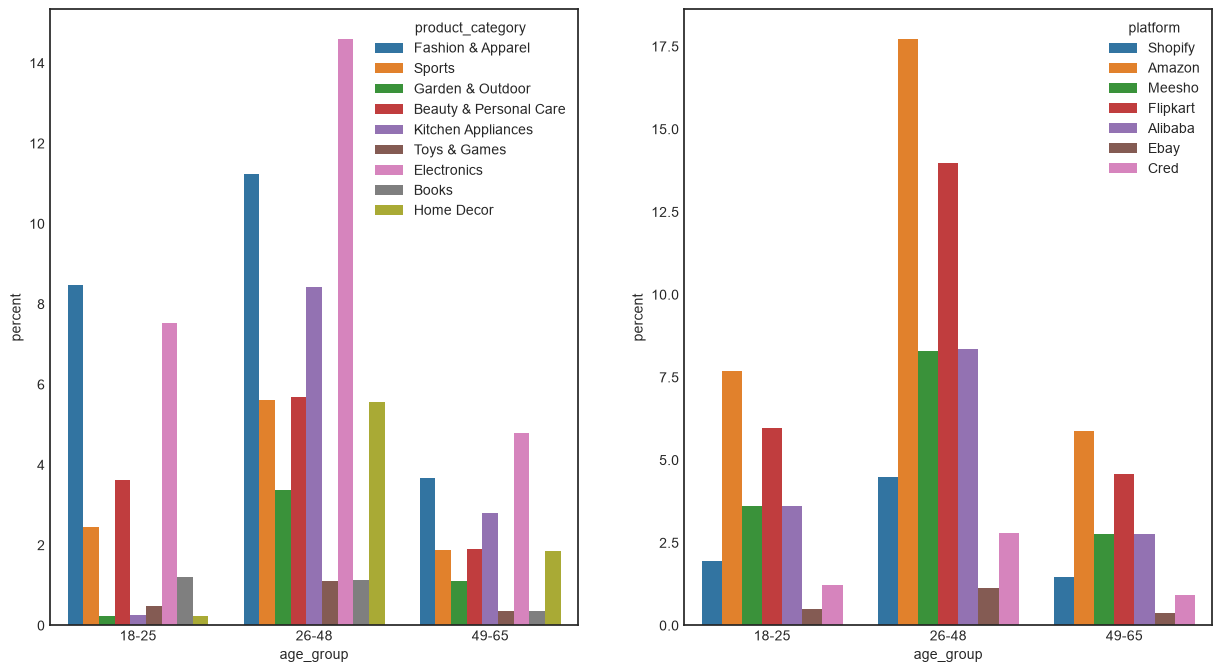

In [185]:
fig , (ax1, ax2) = plt.subplots(1, 2, figsize = (15, 8))
sns.countplot(x = df_merged_1.age_group, hue = df_merged_1.product_category , stat = "percent", ax = ax1)
sns.countplot(x = df_merged_1.age_group, hue = df_merged_1.platform , stat = "percent", ax = ax2)

plt.show()


### Observations:

1. Top 3 purchasing categories of customers in age group (18 -25) : Electronics, Fashion & Apparel, Beauty & personal care
1. Top platforms : Amazon, Flipkart, Alibaba

### Data Visualization: Average Transaction Amount

C:\Users\vaibh\AppData\Local\Temp\ipykernel_19872\588612919.py:19: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=cat_col, y='tran_amount', data=sorted_data, ci=None, ax=axes[i], palette='tab10')
C:\Users\vaibh\AppData\Local\Temp\ipykernel_19872\588612919.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_col, y='tran_amount', data=sorted_data, ci=None, ax=axes[i], palette='tab10')
C:\Users\vaibh\AppData\Local\Temp\ipykernel_19872\588612919.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
C:\Users\vaibh\AppData\Local\Temp\ipykernel_19872\588612919.py:19: FutureWarning: 

The `ci` para

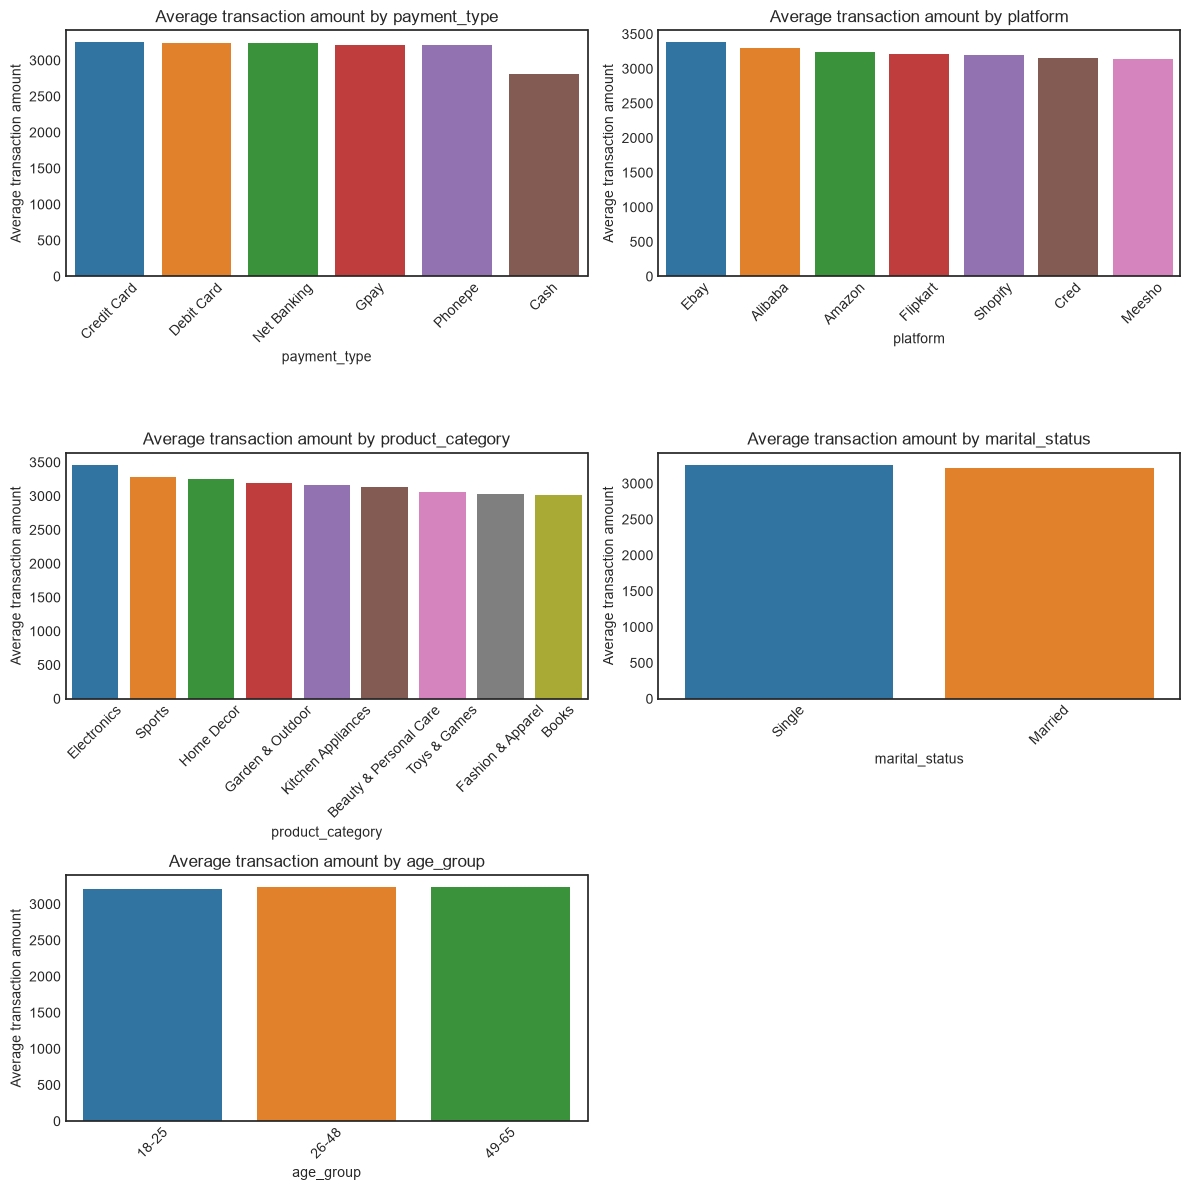

In [188]:
# List of categorical columns
cat_cols = ['payment_type', 'platform', 'product_category', 'marital_status', 'age_group']

num_rows = 3
# Create subplots
fig, axes = plt.subplots(num_rows, 2, figsize=(12, 4 * num_rows))

# Flatten the axes array to make it easier to iterate
axes = axes.flatten()

# Create subplots for each categorical column
for i, cat_col in enumerate(cat_cols):
    # Calculate the average annual income for each category
    avg_tran_amount_by_category = df_merged_1.groupby(cat_col)['tran_amount'].mean().reset_index()

    # Sort the data by 'annual_income' before plotting
    sorted_data = avg_tran_amount_by_category.sort_values(by='tran_amount', ascending=False)

    sns.barplot(x=cat_col, y='tran_amount', data=sorted_data, ci=None, ax=axes[i], palette='tab10')
    axes[i].set_title(f'Average transaction amount by {cat_col}')
    axes[i].set_xlabel(cat_col)
    axes[i].set_ylabel('Average transaction amount')

    # Rotate x-axis labels for better readability
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)

# Hide any unused subplots
for i in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[i])
plt.tight_layout()
plt.show()

### Further Analysis On Age Group

Let us do further analysis on age group to figure out their average income, credit limit, credit score etc

In [189]:
# Group the data by age group and calculate the average credit_limit and credit_score
age_group_metrics = df_merged.groupby('age_group')[['annual_income', 'credit_limit', 'credit_score']].mean().reset_index()
age_group_metrics

,age_group,annual_income,credit_limit,credit_score
0,18-25,37091.235772,1130.081301,484.451220
1,26-48,145869.623457,20560.846561,597.569665
2,49-65,260165.925134,41699.197861,701.524064


C:\Users\vaibh\AppData\Local\Temp\ipykernel_19872\2606875490.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='age_group', y='annual_income', data=age_group_metrics, palette='tab10', ax=ax1)
C:\Users\vaibh\AppData\Local\Temp\ipykernel_19872\2606875490.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='age_group', y='credit_limit', data=age_group_metrics, palette='hls', ax=ax2)
C:\Users\vaibh\AppData\Local\Temp\ipykernel_19872\2606875490.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='age_group', y='credit_score', data=age_g

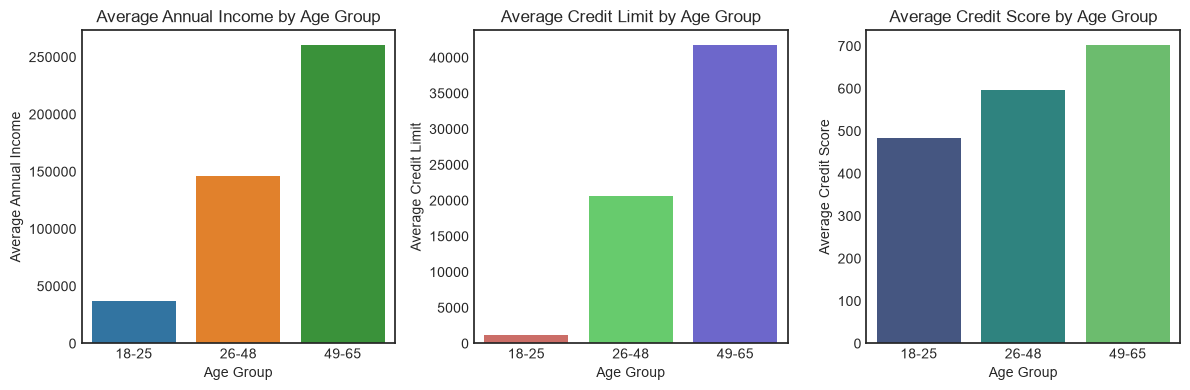

In [190]:
# Create subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))

# Plot 1: Average annual income by age group
sns.barplot(x='age_group', y='annual_income', data=age_group_metrics, palette='tab10', ax=ax1)
ax1.set_title('Average Annual Income by Age Group')
ax1.set_xlabel('Age Group')
ax1.set_ylabel('Average Annual Income')
ax1.tick_params(axis='x', rotation=0)

# Plot 2: Average Max Credit Limit by Age Group
sns.barplot(x='age_group', y='credit_limit', data=age_group_metrics, palette='hls', ax=ax2)
ax2.set_title('Average Credit Limit by Age Group')
ax2.set_xlabel('Age Group')
ax2.set_ylabel('Average Credit Limit')
ax2.tick_params(axis='x', rotation=0)

# Plot 3: Average Credit Score by Age Group
sns.barplot(x='age_group', y='credit_score', data=age_group_metrics, palette='viridis', ax=ax3)
ax3.set_title('Average Credit Score by Age Group')
ax3.set_xlabel('Age Group')
ax3.set_ylabel('Average Credit Score')
ax3.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

<h2 align="center", style="color:purple">Finalize Target Market For a Trial Credit Card Launch<h2>

1. People with age group of 18 -25 accounts to ~26% of customer base in the data
2. Avg annual income of this group is less than 50k
3. They don't have much credit history which is getting reflected in their credit score and credit limit
4. Usage of credit cards as payment type is relatively low compared to other groups
5. Top 3 most shopping products categories : Electronics, Fashion & Apparel, Beauty & Personal care